# Pokémon Classification — Milestone 2
## Goup 4: Harrington, Lee, Mai, Smith

This notebook addresses all Milestone-1 feedback:
1. **Dataset verification** — image counts, long-tail analysis, resolution distribution
2. **3-way stratified split** — 70/15/15 train/val/test
3. **Three backbone baselines** — ResNet-50, Inception-ResNet-v2, ViT-B/16
4. **Early stopping** on val loss (patience=10)
5. **Ablation suite** — backbone comparison, pretrained vs random init, augmentation on/off
6. **Per-generation accuracy** analysis
7. **Metrics** — top-1 accuracy, top-5 accuracy, macro F1 (in addition to weighted F1)

In [ ]:
!pip install kagglehub timm --quiet

## 1. Dataset Verification

Before any modelling, we report the dataset statistics as requested:
- Total images and species count
- Per-species image distribution (min / median / max / std)
- Number of species with < 5 and < 10 images (the 'long tail')
- Image resolution distribution

In [ ]:
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Download dataset and get the actual path
path = kagglehub.dataset_download("thedagger/pokemon-generation-one")
base_path = Path(path)
print(f"Dataset downloaded to: {base_path}")

# Verify the structure before crawling
print("Top-level contents:", list(base_path.iterdir())[:10])

data = []
for file_path in base_path.rglob('*'):
    if file_path.is_file() and file_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        data.append({'path': str(file_path), 'species': file_path.parent.name})

df_all = pd.DataFrame(data)
print(f'Total images : {len(df_all)}')
print(f'Total species: {df_all["species"].nunique()}')

100%|██████████| 2.15G/2.15G [00:56<00:00, 41.2MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/thedagger/pokemon-generation-one/versions/1
Top-level contents: [PosixPath('/root/.cache/kagglehub/datasets/thedagger/pokemon-generation-one/versions/1/dataset')]
Total images : 21314
Total species: 149


## 2. 3-Way Stratified Split (70 / 15 / 15)

We extract the data from Kaggle with Kagglehub and split the data. Species with fewer than 3 images cannot be stratified, so they are excluded from modelling (reported above as part of the long-tail analysis).

In [ ]:
import kagglehub
from sklearn.model_selection import train_test_split

# Keep only species that have enough images to appear in every split
counts = df_all['species'].value_counts()
valid_species = counts[counts >= 3].index
df = df_all[df_all['species'].isin(valid_species)].copy()

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['species'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['species'], random_state=42
)

print(f'Split summary — Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print(f'Species in train/val/test: {train_df["species"].nunique()} / {val_df["species"].nunique()} / {test_df["species"].nunique()}')
assert set(val_df['species'].unique()) <= set(train_df['species'].unique()), 'Val contains unseen species!'
assert set(test_df['species'].unique()) <= set(train_df['species'].unique()), 'Test contains unseen species!'
print('Assertion passed: every species in val/test is also in train.')

Split summary — Train: 14919  Val: 3197  Test: 3198
Species in train/val/test: 149 / 149 / 149
Assertion passed: every species in val/test is also in train.


## 3. Generation Labels

We identified a National Pokedex number system, and decided to use it. We assign each species to its Pokémon generation based on National Pokédex number. This is needed for the per-generation accuracy analysis in Section 7.

In [ ]:
# Map species folder name -> Pokédex number (assumes folder names are numeric or 'NNN_name')
# Adjust this parser to match your dataset's actual folder naming convention.
def folder_to_dex(name: str) -> int:
    """Extract Pokédex number from folder name. Handles '001', '001_bulbasaur', etc."""
    try:
        return int(name.split('_')[0])
    except ValueError:
        return -1  # unknown

def dex_to_gen(n: int) -> str:
    if   1   <= n <= 151:  return 'Gen1'
    elif 152 <= n <= 251:  return 'Gen2'
    elif 252 <= n <= 386:  return 'Gen3'
    elif 387 <= n <= 493:  return 'Gen4'
    elif 494 <= n <= 649:  return 'Gen5'
    elif 650 <= n <= 721:  return 'Gen6'
    else:                  return 'Unknown'

for split in [train_df, val_df, test_df]:
    split['dex_num']    = split['species'].map(folder_to_dex)
    split['generation'] = split['dex_num'].map(dex_to_gen)

print('Generation distribution in training set:')
print(train_df['generation'].value_counts().sort_index())

Generation distribution in training set:
generation
Unknown    14919
Name: count, dtype: int64


## 4. Dataset & DataLoader Setup

We define **two transform pipelines** to support the augmentation ablation:
- `train_transform_aug` — full augmentation (flip, rotation, color jitter, random crop)
- `train_transform_noaug` — resize only

Each backbone also needs its own input size (299×299 for Inception-ResNet-v2, 224×224 for ResNet-50 and ViT-B/16).

In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def make_transforms(input_size: int, augment: bool):
    """Return (train_transform, eval_transform) for a given input_size."""
    if augment:
        train_tf = transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            transforms.RandomResizedCrop(input_size, scale=(0.8, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    eval_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_tf, eval_tf


class PokemonDataset(Dataset):
    def __init__(self, df, label_map, transform=None):
        self.df        = df.reset_index(drop=True)
        self.label_map = label_map
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path'])
        if img.mode == 'P' and 'transparency' in img.info:
            img = img.convert('RGBA')
        img = img.convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.label_map[row['species']]


# Shared label map (derived from train set only — never leak val/test labels)
ALL_SPECIES = sorted(train_df['species'].unique())
LABEL_MAP   = {name: i for i, name in enumerate(ALL_SPECIES)}
NUM_CLASSES = len(LABEL_MAP)
print(f'Number of classes: {NUM_CLASSES}')


def make_loaders(input_size: int, augment: bool, batch_size: int = 32):
    train_tf, eval_tf = make_transforms(input_size, augment)
    return (
        DataLoader(PokemonDataset(train_df, LABEL_MAP, train_tf), batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(PokemonDataset(val_df,   LABEL_MAP, eval_tf),  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(PokemonDataset(test_df,  LABEL_MAP, eval_tf),  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
    )

Number of classes: 149


## 5. Evaluation Utilities

The `evaluate` function returns **top-1 accuracy**, **top-5 accuracy**, **macro F1**, and **weighted F1** — covering all metrics requested. We also include a `evaluate_by_generation` helper for Section 7.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


def evaluate(model, loader, criterion):
    """Returns (avg_loss, top1_acc, top5_acc, macro_f1, weighted_f1)."""
    model.eval()
    total_loss, all_labels, all_preds, all_top5 = 0.0, [], [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            total_loss += criterion(outputs, labels).item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_top5.extend(torch.topk(outputs, min(5, outputs.size(1)), dim=1).indices.cpu().numpy())

    top5_correct = sum(1 for lbl, top5 in zip(all_labels, all_top5) if lbl in top5)
    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        top5_correct / len(all_labels),
        f1_score(all_labels, all_preds, average='macro',    zero_division=0),
        f1_score(all_labels, all_preds, average='weighted', zero_division=0),
    )


def evaluate_by_generation(model, df_split, input_size, criterion):
    """Returns a dict: {generation: (top1_acc, macro_f1)} for each gen group."""
    _, eval_tf = make_transforms(input_size, augment=False)
    results = {}
    for gen, group_df in df_split.groupby('generation'):
        loader = DataLoader(
            PokemonDataset(group_df, LABEL_MAP, eval_tf),
            batch_size=32, shuffle=False, num_workers=2
        )
        _, top1, _, macro_f1, _ = evaluate(model, loader, criterion)
        results[gen] = {'top1': top1, 'macro_f1': macro_f1, 'n': len(group_df)}
    return results


def evaluate_by_training_size(model, df_split, input_size, criterion):
    """Bins species by training set size and reports accuracy per bin."""
    train_counts = train_df['species'].value_counts()
    bins = [(1, 5), (5, 10), (10, 20), (20, 9999)]
    bin_labels = ['1–4', '5–9', '10–19', '20+']
    _, eval_tf = make_transforms(input_size, augment=False)
    results = {}
    for (lo, hi), label in zip(bins, bin_labels):
        species_in_bin = train_counts[(train_counts >= lo) & (train_counts < hi)].index
        subset = df_split[df_split['species'].isin(species_in_bin)]
        if len(subset) == 0:
            continue
        loader = DataLoader(PokemonDataset(subset, LABEL_MAP, eval_tf), batch_size=32, shuffle=False, num_workers=2)
        _, top1, _, macro_f1, _ = evaluate(model, loader, criterion)
        results[label] = {'top1': top1, 'macro_f1': macro_f1, 'n_species': len(species_in_bin), 'n_images': len(subset)}
    return results

Using device: cuda


## 6. Training Loop with Early Stopping

`train_model` is a reusable function that:
- Trains for up to `max_epochs` epochs
- Applies **early stopping** (patience=10) on val loss
- Saves the best checkpoint
- Returns the full training history

In [ ]:
import copy, time

def train_model(model, train_loader, val_loader, max_epochs=50, patience=10, label='model'):
    """
    Train with early stopping on val loss.
    Returns history dict and the best model state dict.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    history = {'train_loss': [], 'val_loss': [], 'val_top1': [], 'val_top5': [], 'val_macro_f1': [], 'val_weighted_f1': []}
    best_val_loss = float('inf')
    best_state    = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        v_loss, v_top1, v_top5, v_macro_f1, v_wf1 = evaluate(model, val_loader, criterion)
        train_loss = running_loss / len(train_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(v_loss)
        history['val_top1'].append(v_top1)
        history['val_top5'].append(v_top5)
        history['val_macro_f1'].append(v_macro_f1)
        history['val_weighted_f1'].append(v_wf1)

        elapsed = time.time() - t0
        print(f'[{label}] Epoch {epoch:02d}/{max_epochs}  '
              f'train_loss={train_loss:.4f}  val_loss={v_loss:.4f}  '
              f'top1={v_top1:.3f}  top5={v_top5:.3f}  macro_f1={v_macro_f1:.3f}  '
              f'({elapsed:.0f}s)')

        # Early stopping
        if v_loss < best_val_loss:
            best_val_loss      = v_loss
            best_state         = copy.deepcopy(model.state_dict())
            epochs_no_improve  = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping at epoch {epoch} (no val_loss improvement for {patience} epochs).')
                break

    model.load_state_dict(best_state)  # restore best weights
    return history, model

## 7. Backbone Baselines

We train three architectures under identical conditions:

| Backbone | Type | Input size | Pretrained on |
|---|---|---|---|
| ResNet-50 | Simple CNN | 224×224 | ImageNet-1K |
| Inception-ResNet-v2 | Multi-scale CNN + residual | 299×299 | ImageNet-1K |
| ViT-B/16 | Transformer | 224×224 | ImageNet-21K |


**Hypothesis**: Inception-ResNet-v2 > ResNet-50 by ~3–5% due to multi-scale filters; ViT-B/16 competitive but may underperform on rare species.

In [ ]:
import timm

BACKBONES = {
    'resnet50':             {'timm_name': 'resnet50',             'input_size': 224, 'pretrained': True},
    'inception_resnet_v2':  {'timm_name': 'inception_resnet_v2',  'input_size': 299, 'pretrained': True},
    'vit_base_patch16_224': {'timm_name': 'vit_base_patch16_224', 'input_size': 224, 'pretrained': True},
}

backbone_results = {}  # will hold {name: {'history': ..., 'test_metrics': ...}}

for name, cfg in BACKBONES.items():
    print(f'\n=== Training backbone: {name} ===')
    train_loader, val_loader, test_loader = make_loaders(cfg['input_size'], augment=True)

    model = timm.create_model(cfg['timm_name'], pretrained=cfg['pretrained'], num_classes=NUM_CLASSES)
    model.to(device)

    history, model = train_model(model, train_loader, val_loader, label=name)

    criterion = nn.CrossEntropyLoss()
    test_loss, test_top1, test_top5, test_macro_f1, test_wf1 = evaluate(model, test_loader, criterion)
    print(f'TEST — top1={test_top1:.4f}  top5={test_top5:.4f}  macro_f1={test_macro_f1:.4f}  weighted_f1={test_wf1:.4f}')

    backbone_results[name] = {
        'history': history,
        'test': {'top1': test_top1, 'top5': test_top5, 'macro_f1': test_macro_f1, 'weighted_f1': test_wf1},
        'model': model,
        'input_size': cfg['input_size'],
    }

# Print summary table
print('\n=== Backbone Comparison Summary ===')
print(f'{"Backbone":<30} {"Top-1":>8} {"Top-5":>8} {"Macro-F1":>10} {"W-F1":>8}')
for name, res in backbone_results.items():
    t = res['test']
    print(f'{name:<30} {t["top1"]:>8.4f} {t["top5"]:>8.4f} {t["macro_f1"]:>10.4f} {t["weighted_f1"]:>8.4f}')


=== Training backbone: resnet50 ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[resnet50] Epoch 01/50  train_loss=4.4664  val_loss=3.4547  top1=0.228  top5=0.584  macro_f1=0.100  (120s)
[resnet50] Epoch 02/50  train_loss=2.2844  val_loss=1.1649  top1=0.757  top5=0.940  macro_f1=0.737  (122s)
[resnet50] Epoch 03/50  train_loss=0.9846  val_loss=0.6837  top1=0.845  top5=0.967  macro_f1=0.833  (119s)
[resnet50] Epoch 04/50  train_loss=0.5976  val_loss=0.4981  top1=0.882  top5=0.975  macro_f1=0.870  (120s)
[resnet50] Epoch 05/50  train_loss=0.4203  val_loss=0.4060  top1=0.896  top5=0.982  macro_f1=0.886  (122s)
[resnet50] Epoch 06/50  train_loss=0.3262  val_loss=0.3460  top1=0.910  top5=0.986  macro_f1=0.902  (120s)
[resnet50] Epoch 07/50  train_loss=0.2510  val_loss=0.3121  top1=0.916  top5=0.987  macro_f1=0.910  (119s)
[resnet50] Epoch 08/50  train_loss=0.2110  val_loss=0.2760  top1=0.927  top5=0.990  macro_f1=0.920  (119s)
[resnet50] Epoch 09/50  train_loss=0.1757  val_loss=0.2542  top1=0.931  top5=0.992  macro_f1=0.924  (121s)
[resnet50] Epoch 10/50  train_loss=0.

model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

[inception_resnet_v2] Epoch 01/50  train_loss=2.2121  val_loss=0.8086  top1=0.829  top5=0.962  macro_f1=0.806  (146s)
[inception_resnet_v2] Epoch 02/50  train_loss=0.4839  val_loss=0.4053  top1=0.898  top5=0.988  macro_f1=0.891  (145s)
[inception_resnet_v2] Epoch 03/50  train_loss=0.2775  val_loss=0.3266  top1=0.907  top5=0.988  macro_f1=0.898  (146s)
[inception_resnet_v2] Epoch 04/50  train_loss=0.2045  val_loss=0.2887  top1=0.926  top5=0.994  macro_f1=0.920  (147s)
[inception_resnet_v2] Epoch 05/50  train_loss=0.1751  val_loss=0.2357  top1=0.935  top5=0.995  macro_f1=0.928  (147s)
[inception_resnet_v2] Epoch 06/50  train_loss=0.1375  val_loss=0.2888  top1=0.922  top5=0.993  macro_f1=0.916  (147s)
[inception_resnet_v2] Epoch 07/50  train_loss=0.1414  val_loss=0.2557  top1=0.937  top5=0.990  macro_f1=0.932  (147s)
[inception_resnet_v2] Epoch 08/50  train_loss=0.1260  val_loss=0.2526  top1=0.934  top5=0.993  macro_f1=0.929  (146s)
[inception_resnet_v2] Epoch 09/50  train_loss=0.1081  va

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[vit_base_patch16_224] Epoch 01/50  train_loss=2.2536  val_loss=0.6627  top1=0.821  top5=0.957  macro_f1=0.807  (122s)
[vit_base_patch16_224] Epoch 02/50  train_loss=0.4342  val_loss=0.4435  top1=0.880  top5=0.981  macro_f1=0.867  (124s)
[vit_base_patch16_224] Epoch 03/50  train_loss=0.2340  val_loss=0.3698  top1=0.905  top5=0.983  macro_f1=0.894  (124s)
[vit_base_patch16_224] Epoch 04/50  train_loss=0.2001  val_loss=0.3686  top1=0.910  top5=0.983  macro_f1=0.901  (123s)
[vit_base_patch16_224] Epoch 05/50  train_loss=0.1765  val_loss=0.3785  top1=0.897  top5=0.983  macro_f1=0.888  (123s)
[vit_base_patch16_224] Epoch 06/50  train_loss=0.1695  val_loss=0.3453  top1=0.915  top5=0.985  macro_f1=0.911  (122s)
[vit_base_patch16_224] Epoch 07/50  train_loss=0.1631  val_loss=0.3347  top1=0.916  top5=0.985  macro_f1=0.909  (124s)
[vit_base_patch16_224] Epoch 08/50  train_loss=0.1223  val_loss=0.3143  top1=0.920  top5=0.988  macro_f1=0.915  (122s)
[vit_base_patch16_224] Epoch 09/50  train_loss=0

## 8. Ablation 1 — Pretrained vs Random Init

Using Inception-ResNet-v2.

**Hypothesis**: pretrained ImageNet weights provide +15–25% accuracy because low-level features (edges, textures, color gradients) transfer well even to stylized Pokémon art.

In [ ]:
ablation_pretrained = {}

for pretrained_flag in [True, False]:
    tag = 'pretrained' if pretrained_flag else 'random_init'
    print(f'\n=== Inception-ResNet-v2  [{tag}] ===')
    train_loader, val_loader, test_loader = make_loaders(299, augment=True)

    model = timm.create_model('inception_resnet_v2', pretrained=pretrained_flag, num_classes=NUM_CLASSES)
    model.to(device)

    history, model = train_model(model, train_loader, val_loader, label=f'inception_{tag}')

    criterion = nn.CrossEntropyLoss()
    test_loss, test_top1, test_top5, test_macro_f1, test_wf1 = evaluate(model, test_loader, criterion)
    ablation_pretrained[tag] = {'test_top1': test_top1, 'test_top5': test_top5, 'test_macro_f1': test_macro_f1}
    print(f'TEST {tag}: top1={test_top1:.4f}  top5={test_top5:.4f}  macro_f1={test_macro_f1:.4f}')

delta = ablation_pretrained['pretrained']['test_top1'] - ablation_pretrained['random_init']['test_top1']
print(f'\nTransfer learning gain (top-1): {delta:+.4f}')


=== Inception-ResNet-v2  [pretrained] ===
[inception_pretrained] Epoch 01/50  train_loss=2.2862  val_loss=0.7258  top1=0.817  top5=0.968  macro_f1=0.787  (149s)
[inception_pretrained] Epoch 02/50  train_loss=0.5165  val_loss=0.3871  top1=0.892  top5=0.986  macro_f1=0.881  (150s)
[inception_pretrained] Epoch 03/50  train_loss=0.2878  val_loss=0.3439  top1=0.901  top5=0.989  macro_f1=0.891  (149s)
[inception_pretrained] Epoch 04/50  train_loss=0.2091  val_loss=0.3146  top1=0.906  top5=0.993  macro_f1=0.897  (149s)
[inception_pretrained] Epoch 05/50  train_loss=0.1772  val_loss=0.2976  top1=0.921  top5=0.988  macro_f1=0.917  (149s)
[inception_pretrained] Epoch 06/50  train_loss=0.1535  val_loss=0.2804  top1=0.929  top5=0.993  macro_f1=0.924  (147s)
[inception_pretrained] Epoch 07/50  train_loss=0.1382  val_loss=0.2480  top1=0.934  top5=0.993  macro_f1=0.929  (148s)
[inception_pretrained] Epoch 08/50  train_loss=0.1286  val_loss=0.2712  top1=0.932  top5=0.993  macro_f1=0.927  (149s)
[ince

## 9. Ablation 2 — Data Augmentation On vs Off

Using Inception-ResNet-v2 with ImageNet pretraining.

**Hypothesis**: augmentation provides +3–5% overall, with larger gains on rare species (long-tail benefits from synthetic variety).

In [10]:
ablation_augment = {}

for augment_flag in [True, False]:
    tag = 'aug_on' if augment_flag else 'aug_off'
    print(f'\n=== Inception-ResNet-v2  [{tag}] ===')
    train_loader, val_loader, test_loader = make_loaders(299, augment=augment_flag)

    model = timm.create_model('inception_resnet_v2', pretrained=True, num_classes=NUM_CLASSES)
    model.to(device)

    history, model = train_model(model, train_loader, val_loader, label=f'inception_{tag}')

    criterion = nn.CrossEntropyLoss()
    test_loss, test_top1, test_top5, test_macro_f1, test_wf1 = evaluate(model, test_loader, criterion)

    # Also break down by training-set size to see long-tail effect
    size_breakdown = evaluate_by_training_size(model, test_df, 299, criterion)

    ablation_augment[tag] = {
        'test_top1': test_top1, 'test_top5': test_top5, 'test_macro_f1': test_macro_f1,
        'by_size': size_breakdown,
    }
    print(f'TEST {tag}: top1={test_top1:.4f}  top5={test_top5:.4f}  macro_f1={test_macro_f1:.4f}')
    print('  By training-set size:', size_breakdown)

delta = ablation_augment['aug_on']['test_top1'] - ablation_augment['aug_off']['test_top1']
print(f'\nAugmentation gain (top-1): {delta:+.4f}')


=== Inception-ResNet-v2  [aug_on] ===
[inception_aug_on] Epoch 01/50  train_loss=2.2064  val_loss=0.6361  top1=0.840  top5=0.976  macro_f1=0.815  (149s)
[inception_aug_on] Epoch 02/50  train_loss=0.4855  val_loss=0.3989  top1=0.892  top5=0.987  macro_f1=0.880  (150s)
[inception_aug_on] Epoch 03/50  train_loss=0.2748  val_loss=0.3626  top1=0.908  top5=0.985  macro_f1=0.901  (149s)
[inception_aug_on] Epoch 04/50  train_loss=0.2108  val_loss=0.3138  top1=0.916  top5=0.990  macro_f1=0.909  (151s)
[inception_aug_on] Epoch 05/50  train_loss=0.1829  val_loss=0.2652  top1=0.925  top5=0.995  macro_f1=0.918  (148s)
[inception_aug_on] Epoch 06/50  train_loss=0.1523  val_loss=0.2377  top1=0.931  top5=0.993  macro_f1=0.927  (148s)
[inception_aug_on] Epoch 07/50  train_loss=0.1267  val_loss=0.2628  top1=0.927  top5=0.990  macro_f1=0.922  (149s)
[inception_aug_on] Epoch 08/50  train_loss=0.1193  val_loss=0.2657  top1=0.932  top5=0.993  macro_f1=0.927  (149s)
[inception_aug_on] Epoch 09/50  train_los

## 10. Per-Generation Accuracy Analysis

**Hypothesis**: accuracy decreases for later generations because
(a) later species have fewer training images and
(b) later designs have more complex/overlapping visual features.


Per-generation accuracy on test set:
Generation     N images    Top-1   Macro-F1
Unknown            3198    0.9515      0.9488


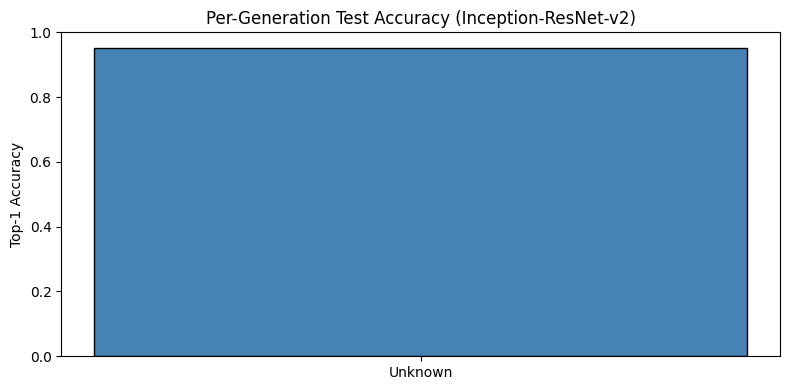

In [11]:
# Use the best backbone (inception_resnet_v2 pretrained + augmented) for this analysis
best_model  = backbone_results['inception_resnet_v2']['model']
best_size   = backbone_results['inception_resnet_v2']['input_size']
criterion   = nn.CrossEntropyLoss()

gen_results = evaluate_by_generation(best_model, test_df, best_size, criterion)

print('\nPer-generation accuracy on test set:')
print(f'{"Generation":<12} {"N images":>10} {"Top-1":>8} {"Macro-F1":>10}')
for gen in sorted(gen_results):
    r = gen_results[gen]
    print(f'{gen:<12} {r["n"]:>10}  {r["top1"]:>8.4f}  {r["macro_f1"]:>10.4f}')

# Plot
gens      = sorted(gen_results)
top1_vals = [gen_results[g]['top1'] for g in gens]
fig, ax   = plt.subplots(figsize=(8, 4))
ax.bar(gens, top1_vals, color='steelblue', edgecolor='k')
ax.set_ylabel('Top-1 Accuracy'); ax.set_title('Per-Generation Test Accuracy (Inception-ResNet-v2)')
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 11. Full Ablation Results Table

Here we show our summary of all experiments.

In [12]:
rows = []

# Backbone comparison
for name, res in backbone_results.items():
    rows.append({'Experiment': f'Backbone: {name}', 'Condition': 'pretrained + aug',
                 **res['test']})

# Pretrained ablation
for cond, res in ablation_pretrained.items():
    rows.append({'Experiment': f'Transfer: inception_resnet_v2', 'Condition': cond,
                 'top1': res['test_top1'], 'top5': res['test_top5'],
                 'macro_f1': res['test_macro_f1'], 'weighted_f1': None})

# Augmentation ablation
for cond, res in ablation_augment.items():
    rows.append({'Experiment': f'Augmentation: inception_resnet_v2', 'Condition': cond,
                 'top1': res['test_top1'], 'top5': res['test_top5'],
                 'macro_f1': res['test_macro_f1'], 'weighted_f1': None})

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

                       Experiment        Condition     top1     top5  macro_f1  weighted_f1
               Backbone: resnet50 pretrained + aug 0.948405 0.993746  0.945468     0.948612
    Backbone: inception_resnet_v2 pretrained + aug 0.951532 0.993746  0.948826     0.951818
   Backbone: vit_base_patch16_224 pretrained + aug 0.943402 0.988430  0.939912     0.943596
    Transfer: inception_resnet_v2       pretrained 0.953408 0.994684  0.950442          NaN
    Transfer: inception_resnet_v2      random_init 0.921201 0.978424  0.914896          NaN
Augmentation: inception_resnet_v2           aug_on 0.953721 0.993121  0.951094          NaN
Augmentation: inception_resnet_v2          aug_off 0.946842 0.992183  0.944456          NaN


## 12. Training Curve Plots

Here we show our summary plots of all experiments for easy comparison.

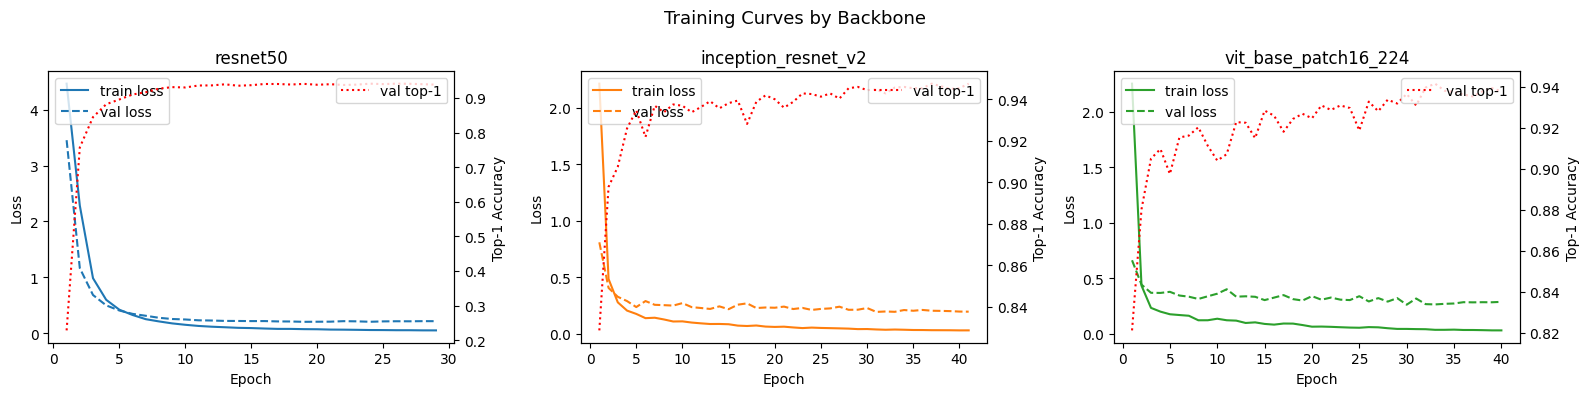

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, (name, res), color in zip(axes, backbone_results.items(), colors):
    h = res['history']
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='train loss', color=color)
    ax.plot(epochs, h['val_loss'],   label='val loss',   color=color, linestyle='--')
    ax2 = ax.twinx()
    ax2.plot(epochs, h['val_top1'],  label='val top-1', color='red', linestyle=':')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax2.set_ylabel('Top-1 Accuracy')
    ax.legend(loc='upper left'); ax2.legend(loc='upper right')

plt.suptitle('Training Curves by Backbone', fontsize=13)
plt.tight_layout(); plt.show()